<a href="https://colab.research.google.com/github/saraisabella0206-ctrl/INTEGRACION-DE-DATOS-Y-PROSPECTIVA-/blob/main/Reto_4_Integraci%C3%B3n_Multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integración Multidimensional — Caso Fintech (Reto 4)**
Por: Sara Isabella Castaño Ramírez


Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a cada uno de sus solicitantes de crédito, para lo cual la entidad financiera quiere llevar a cabo un proceso de integración multidimensional de los datos a cinco sucursales.

Las variables utilizadas para esta integración se basan principalmente en las variables numéricas de:

- Edad - edad del solicitante en años
- Hijos - número de hijos
- Personas a Cargo - además de los hijos, las personas a cargo
- Estrato - socioeconómico (1-6)
- Ingresos - ingresos mensuales en USD
- Egresos - egresos mensuales en USD
- Monto (EAD) - Monto solicitado del crédito en USD
- Plazo - plazo del crédito en meses
- Cuota del crédito. - valor cuota mensual en COP

Para esta integración se empleará el método K-Medoids (integración dinámica multidimensional), usando como semillas iniciales los cinco primeros solicitantes del conjunto de datos ofuscado. Para cada cluster resultante se determinará: el número de clientes, los municipios de procedencia y el porcentaje de preaprobación o prenegación. Los perfiles de cada sucursal se visualizarán mediante gráficos.

## 0. Se cargan las librerías de trabajo

In [35]:
# Importo las librerías que voy a necesitar durante todo el taller
import numpy as np          # Para operaciones matemáticas y manejo de arreglos
import pandas as pd         # Para cargar y manipular el dataframe
import matplotlib.pyplot as plt  # Para crear las gráficas
import seaborn as sns       # Para gráficas estadísticas con mejor estética

# Monto mi Google Drive para poder acceder al archivo de Excel
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Carga de los archivos de trabajo

In [36]:
# Defino la ruta donde está guardado el archivo de Excel con los datos de los solicitantes
nxl = '/content/drive/MyDrive/Colab Notebooks/Excels/4. SolicitantesCrédito(USD)_Municipios.xlsx'

# Cargo el archivo en un dataframe
XDB = pd.read_excel(nxl)

# Ofusco los datos: los desordeno aleatoriamente para eliminar cualquier sesgo de orden
# y dejar el modelo listo para K-Medoids. Uso random_state=42 para que el resultado sea reproducible
XDB = XDB.sample(frac=1, random_state=42).reset_index(drop=True)

# Elimino posibles registros con datos faltantes
XDB = XDB.dropna()

# Muestro las dimensiones del dataframe y los primeros registros para verificar
print('Dimensiones del dataframe:', XDB.shape)
XDB.head()

Dimensiones del dataframe: (5842, 38)


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,6556,63,NR,Unión Libre,1,1,1,3,Bachiller,Ninguno,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.233305,474.284668,0.473965,94.814667,Caldas
1,239,31,Mujer,Soltero,0,1,1,2,Tecnólogo,Indefinido,...,Buena Experiencia CFB,Fondo de Garantia,Prop.sin Hipoteca,Con Experiencia sin Mora,0,0.254857,322.984283,0.386951,-59.363306,Caldas
2,226,61,NR,Casado,7,3,3,2,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.089151,619.955383,0.156131,175.430444,Sabaneta
3,8017,42,Mujer,Soltero,2,1,1,3,Tecnólogo,Fijo,...,Buena Experiencia CFB,Libranza Establecida,Sin Patrimonio,Una mora 60 Dìas,0,0.157716,486.018250,0.292610,265.696222,Caldas
4,3334,32,Mujer,Soltero,1,1,1,4,Bachiller,Indefinido,...,Buenas Referencias,Fondo de Garantia,Sin Patrimonio,Con Experiencia sin Mora,0,0.089574,517.180481,0.155736,406.870611,Itagüí


**Análisis de resultados:**

- El conjunto de datos cuenta con 5.842 registros y 38 variables, correspondientes a solicitantes de crédito provenientes de seis municipios del Área Metropolitana de Medellín: Caldas, Sabaneta, Bello, Itagüí, Medellín y Envigado.


## 2. Se crean las semillas de integración

Los 5 primeros registros de la base de datos ofuscada (desordenada) se convierten en las semillas de integración del modelo K-Medoids. Cada semilla representa el punto de partida de una de las cinco sucursales futuras.

In [37]:
# Defino las columnas numéricas que voy a usar para la integración,
variables_num = ['Edad', 'Hijos', 'Perscargo', 'Estrato',
                 'Ingresos', 'Egresos', 'Monto (EAD)', 'Plazo', 'Cuota (COP)']

# Extraigo solo las columnas numéricas del dataframe y las convierto a arreglo numpy
# para poder hacer operaciones matemáticas sobre ellas
XD = np.array(XDB[variables_num])   # Todos los datos numéricos

# Tomo los primeros 5 registros como semillas (puntos de partida de cada cluster)
XC = np.array(XDB[variables_num].iloc[0:5])  # Semillas = primeros 5 solicitantes

# Creo un vector de ceros con el mismo número de filas que XD
# Este vector va a guardar a qué cluster pertenece cada solicitante
nc = np.zeros((len(XD), 1))

# Muestro las semillas iniciales para verificar
df_semillas = pd.DataFrame(XC, columns=variables_num)
df_semillas.index = [f'Semilla {i+1}' for i in range(5)]
print('Semillas iniciales de integración:')
display(df_semillas)

Semillas iniciales de integración:


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Semilla 1,63.0,1.0,1.0,3.0,176.33400,81.519333,172.442108,48.0,5.065487
Semilla 2,31.0,0.0,1.0,2.0,315.82025,375.183556,137.735049,36.0,4.979452
Semilla 3,61.0,7.0,3.0,2.0,915.54600,740.115556,723.590181,48.0,21.255461
Semilla 4,42.0,2.0,1.0,3.0,483.95200,218.255778,501.956390,48.0,14.744969
Semilla 5,32.0,1.0,1.0,4.0,817.09350,410.222889,819.789060,36.0,29.637338


## 3. Se procede con la integración multidimensional (K-Medoids)

In [38]:
# Aplico el algoritmo K-Medoids dinámico:
# Para cada solicitante calculo su distancia relativa a cada una de las 5 semillas,
# lo asigno al cluster más cercano, y actualizo ese centroide con el promedio acumulado

for k in range(len(XD)):
    # Extraigo los datos del solicitante k
    Xind = XD[k, ]

    # Calculo la distancia relativa cuadrática entre el solicitante y cada semilla
    # Uso distancia relativa (dividiendo por el centroide) para que todas las variables
    # tengan el mismo peso sin importar su escala
    # Evito dividir por cero reemplazando semillas en cero por un valor muy pequeño
    XC_safe = np.where(XC == 0, 1e-10, XC)
    m1 = np.sum(((XC_safe[:, ] - Xind) / XC_safe[:, ]) ** 2, axis=1)

    # Asigno el solicitante al cluster con menor distancia
    nc[k] = np.argmin(m1)

    # Identifico el número del cluster ganador
    cluster = int(np.argmin(m1))

    # Actualizo el centroide del cluster ganador promediando con el nuevo solicitante
    XC[cluster, ] = (XC[cluster, ] + Xind) / 2

# Guardo los centroides finales en un dataframe para mostrarlos
dfxc = pd.DataFrame(XC, columns=variables_num)
dfxc.index = [f'Sucursal {i+1}' for i in range(5)]

print('Centroides finales de cada sucursal:')
display(dfxc)

# Cuento cuántos solicitantes quedaron en cada cluster
ND = []
for j in range(5):
    nd = len(np.where(nc[:, ] == j)[0])
    print(f'Número de solicitantes en la Sucursal {j+1}: {nd}')
    ND.append(nd)

# Agrego la columna de número de datos al dataframe de centroides
dfxc['N_Solicitantes'] = ND

Centroides finales de cada sucursal:


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,27.172960,1.539585e-01,1.563630e+00,2.045467,490.902385,514.509391,333.741282,23.138103,30.648833
Sucursal 2,61.523617,0.000000e+00,2.967458e-18,1.528630,37.198014,39.860188,22.471168,29.685900,1.039495
Sucursal 3,38.182155,2.118482e-35,6.291945e-71,1.919945,247.872170,195.816940,230.158428,31.843830,9.104286
Sucursal 4,45.856655,1.622914e-09,3.794708e-19,3.264059,8.967958,7.188258,4.769350,32.051411,0.210584
Sucursal 5,56.708729,1.295425e-77,2.159042e-78,4.003433,50.869748,50.775259,31.918182,35.465218,1.183425


Número de solicitantes en la Sucursal 1: 4973
Número de solicitantes en la Sucursal 2: 131
Número de solicitantes en la Sucursal 3: 412
Número de solicitantes en la Sucursal 4: 66
Número de solicitantes en la Sucursal 5: 260


Para rectificar que estan bien distribuidos sumo el número de solicitantes en cada sucursal y me da exactamente la cantidad inicial del data frame (5.842).

## 4. Se determinan los perfiles de los solicitantes por cluster

In [39]:
# Creo una matriz vacía de 5 filas (clusters) x 9 columnas (variables numéricas)
# para almacenar el perfil promedio de cada sucursal
PRC = np.zeros((5, len(variables_num)))

# Extraigo solo las columnas numéricas del dataframe para calcular los promedios
XDB_num = XDB[variables_num]

# Para cada cluster calculo el promedio de cada variable numérica
# Esto me da el perfil típico del solicitante que atiende cada sucursal
for j in range(5):
    filas = np.where(nc == j)[0]    # Identifico las filas que pertenecen al cluster j
    df2 = XDB_num.iloc[filas, ]    # Extraigo esos registros
    PRC[j, ] = np.mean(df2, axis=0) # Calculo el promedio de cada variable

    # Muestro el perfil de cada sucursal de forma clara
    df3 = pd.DataFrame(np.mean(df2, axis=0)).T
    df3.columns = variables_num
    df3.index = [f'Sucursal {j+1}']
    display(df3)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 1,40.986929,1.160668,0.93887,2.91856,743.35418,660.27508,547.07335,32.495677,31.13067


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 2,41.671756,0.0,0.664122,2.740458,502.423708,463.413983,336.383967,35.358779,18.36491


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 3,40.56068,1.082524,0.449029,2.813107,565.465445,519.217016,397.17908,33.021845,19.973848


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 4,46.515152,0.818182,0.060606,2.878788,488.896117,439.374993,374.097282,30.863636,18.125665


,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
Sucursal 5,41.219231,0.015385,0.007692,3.073077,839.595465,754.891246,598.433891,32.1,31.658277


## 5. Se analiza la distribución por municipio en cada sucursal

Distribución de solicitantes por municipio y sucursal:


Sucursal,Sucursal 1,Sucursal 2,Sucursal 3,Sucursal 4,Sucursal 5
Municipio,,,,,
Bello,922,14,44,9,58
Caldas,1522,71,192,38,55
Envigado,71,1,2,0,3
Itagüí,491,15,45,9,28
Medellín,395,7,19,3,24
Sabaneta,1572,23,110,7,92


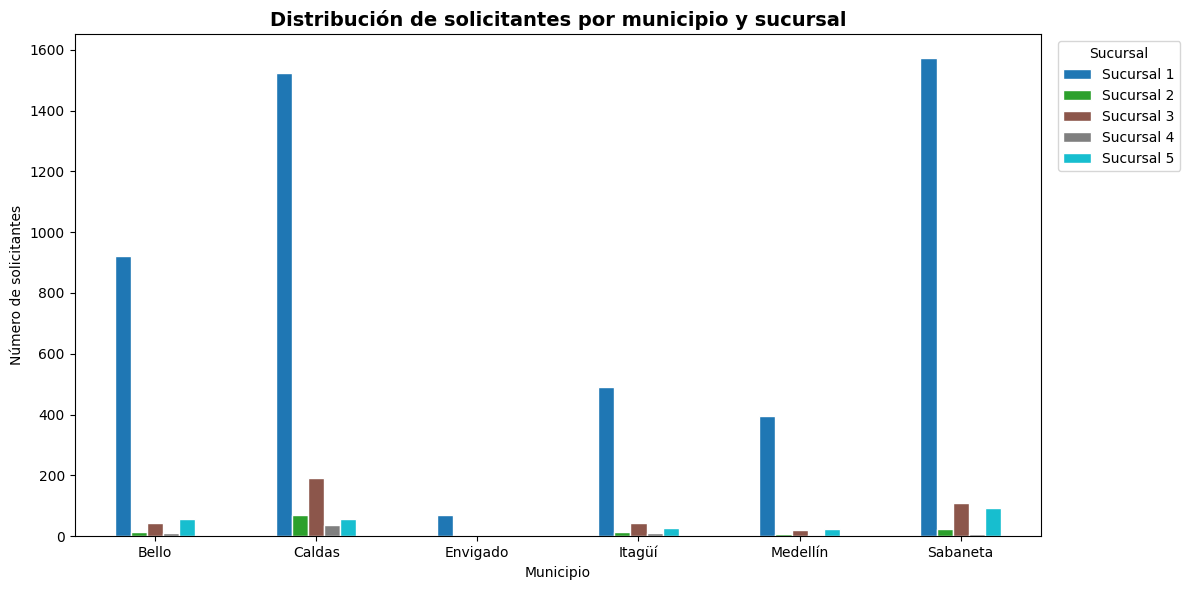

In [40]:
# Agrego la columna de cluster al dataframe original para poder analizar
# la procedencia por municipio de los solicitantes de cada sucursal
XDB['Cluster'] = nc.astype(int)
XDB['Sucursal'] = XDB['Cluster'].apply(lambda x: f'Sucursal {x+1}')

# Genero una tabla cruzada que muestra cuántos solicitantes de cada municipio
# quedaron asignados a cada sucursal
tabla_municipios = pd.crosstab(XDB['Municipio'], XDB['Sucursal'])
print('Distribución de solicitantes por municipio y sucursal:')
display(tabla_municipios)

# Visualizo la distribución con un gráfico de barras agrupadas
# Este gráfico me permite comparar fácilmente cómo se distribuyen
# los municipios en cada una de las cinco sucursales
tabla_municipios.plot(
    kind='bar',
    figsize=(12, 6),
    colormap='tab10',
    edgecolor='white'
)
plt.title('Distribución de solicitantes por municipio y sucursal', fontsize=14, fontweight='bold')
plt.xlabel('Municipio')
plt.ylabel('Número de solicitantes')
plt.legend(title='Sucursal', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Se analiza el porcentaje de preaprobación y prenegación por sucursal

ANÁLISIS DE PREAPROBACIÓN POR SUCURSAL

Sucursal 1 (4973 solicitantes):
  ✔ Preaprobados : 2526 (50.8%)
  ✘ Prenegados   : 2447  (49.2%)

Sucursal 2 (131 solicitantes):
  ✔ Preaprobados : 43 (32.8%)
  ✘ Prenegados   : 88  (67.2%)

Sucursal 3 (412 solicitantes):
  ✔ Preaprobados : 150 (36.4%)
  ✘ Prenegados   : 262  (63.6%)

Sucursal 4 (66 solicitantes):
  ✔ Preaprobados : 21 (31.8%)
  ✘ Prenegados   : 45  (68.2%)

Sucursal 5 (260 solicitantes):
  ✔ Preaprobados : 143 (55.0%)
  ✘ Prenegados   : 117  (45.0%)


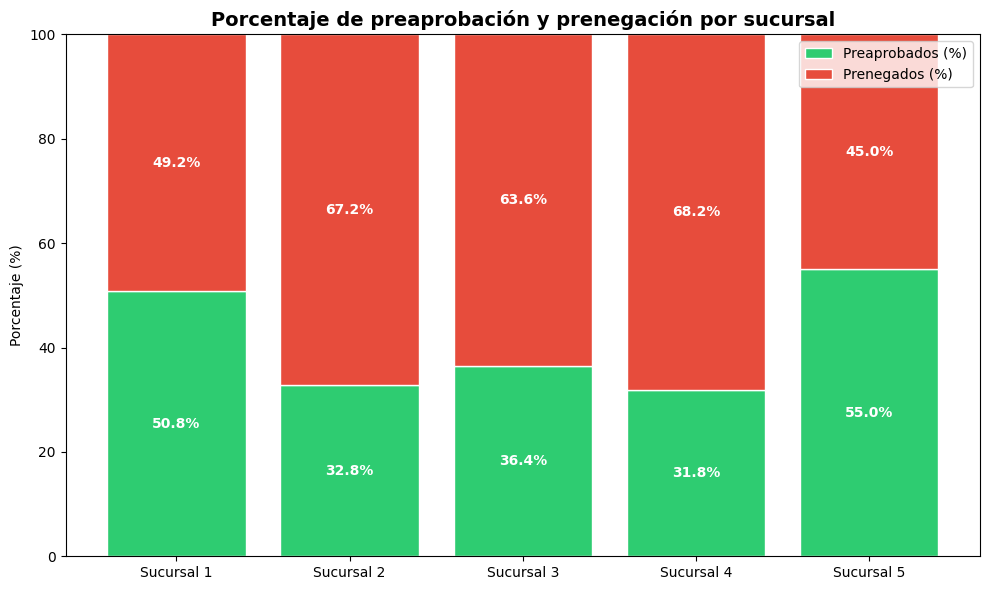

In [41]:
# Calculo el porcentaje de preaprobación (PreApr=1) y prenegación (PreApr=0)
# para cada una de las cinco sucursales resultantes

print('=' * 60)
print('ANÁLISIS DE PREAPROBACIÓN POR SUCURSAL')
print('=' * 60)

# Listas para guardar los porcentajes y poder graficarlos luego
porc_aprobados = []
porc_negados = []

for j in range(5):
    # Identifico las filas que pertenecen al cluster j
    filas = np.where(nc[:, ] == j)[0]

    # Cuento cuántos fueron preaprobados (PreApr = 1) y prenegados (PreApr = 0)
    n_total = len(filas)
    n_aprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_negados = len(np.where(XDB.iloc[filas]['PreApr'] == 0)[0])

    # Calculo los porcentajes
    p_aprobados = n_aprobados / n_total * 100
    p_negados = n_negados / n_total * 100

    porc_aprobados.append(p_aprobados)
    porc_negados.append(p_negados)

    print(f'\nSucursal {j+1} ({n_total} solicitantes):')
    print(f'  ✔ Preaprobados : {n_aprobados} ({p_aprobados:.1f}%)')
    print(f'  ✘ Prenegados   : {n_negados}  ({p_negados:.1f}%)')

# Grafico el resultado con barras apiladas para ver de un vistazo
# la proporción aprobado/negado en cada sucursal
sucursales = [f'Sucursal {j+1}' for j in range(5)]

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(sucursales, porc_aprobados, label='Preaprobados (%)', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(sucursales, porc_negados, bottom=porc_aprobados, label='Prenegados (%)', color='#e74c3c', edgecolor='white')

# Agrego etiquetas dentro de cada barra para facilitar la lectura
for i, (b1, b2) in enumerate(zip(bars1, bars2)):
    ax.text(b1.get_x() + b1.get_width() / 2, b1.get_height() / 2,
            f'{porc_aprobados[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')
    ax.text(b2.get_x() + b2.get_width() / 2, porc_aprobados[i] + b2.get_height() / 2,
            f'{porc_negados[i]:.1f}%', ha='center', va='center', color='white', fontweight='bold')

ax.set_title('Porcentaje de preaprobación y prenegación por sucursal', fontsize=14, fontweight='bold')
ax.set_ylabel('Porcentaje (%)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Tabla resumen consolidada por sucursal

In [42]:
# Construyo una tabla resumen que consolida toda la información relevante
# para que la empresa pueda tomar decisiones de manera rápida e informada

resumen = []

for j in range(5):
    filas = np.where(nc[:, ] == j)[0]
    n_total = len(filas)

    # Municipio con más solicitantes en esta sucursal
    municipio_top = XDB.iloc[filas]['Municipio'].value_counts().idxmax()
    municipios_lista = ', '.join(XDB.iloc[filas]['Municipio'].value_counts().index.tolist())

    # Porcentajes de aprobación
    n_aprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    p_aprobados = round(n_aprobados / n_total * 100, 1)
    p_negados = round(100 - p_aprobados, 1)

    resumen.append({
        'Sucursal': f'Sucursal {j+1}',
        'N° Solicitantes': n_total,
        'Municipio principal': municipio_top,
        'Municipios atendidos': municipios_lista,
        'Preaprobados (%)': p_aprobados,
        'Prenegados (%)': p_negados
    })

df_resumen = pd.DataFrame(resumen).set_index('Sucursal')
print('Tabla resumen por sucursal:')
display(df_resumen)

Tabla resumen por sucursal:


,N° Solicitantes,Municipio principal,Municipios atendidos,Preaprobados (%),Prenegados (%)
Sucursal,,,,,
Sucursal 1,4973,Sabaneta,"Sabaneta, Caldas, Bello, Itagüí, Medellín, Env...",50.8,49.2
Sucursal 2,131,Caldas,"Caldas, Sabaneta, Itagüí, Bello, Medellín, Env...",32.8,67.2
Sucursal 3,412,Caldas,"Caldas, Sabaneta, Itagüí, Bello, Medellín, Env...",36.4,63.6
Sucursal 4,66,Caldas,"Caldas, Bello, Itagüí, Sabaneta, Medellín",31.8,68.2
Sucursal 5,260,Sabaneta,"Sabaneta, Bello, Caldas, Itagüí, Medellín, Env...",55.0,45.0


## 8. Gráfico de araña — Perfiles multidimensionales por sucursal

In [43]:
# El gráfico de araña (radar chart) es ideal para comparar múltiples variables
# al mismo tiempo entre los diferentes clusters.
# Primero normalizo los datos entre 0 y 1 para que todas las variables
# tengan el mismo peso visual, sin importar su escala original

features = variables_num  # Las variables que forman los ejes del gráfico

df_prc = pd.DataFrame(PRC, columns=features)

# Calculo los mínimos y máximos de cada variable para la normalización
min_vals = df_prc.min()
max_vals = df_prc.max()

normalized_data = []

# Normalizo cada fila (cluster) dividiendo por el rango de cada variable
for i in range(len(df_prc)):
    row_data = df_prc.iloc[i].copy()
    normalized_row = {}
    for feature in features:
        min_val = min_vals[feature]
        max_val = max_vals[feature]
        # Si el rango es cero (todos los clusters tienen el mismo valor), pongo 0
        if max_val == min_val:
            normalized_row[feature] = 0.0
        else:
            normalized_row[feature] = (row_data[feature] - min_val) / (max_val - min_val)
    normalized_row['Cluster'] = f'Sucursal {i+1}'
    normalized_data.append(normalized_row)

df_normalized = pd.DataFrame(normalized_data)

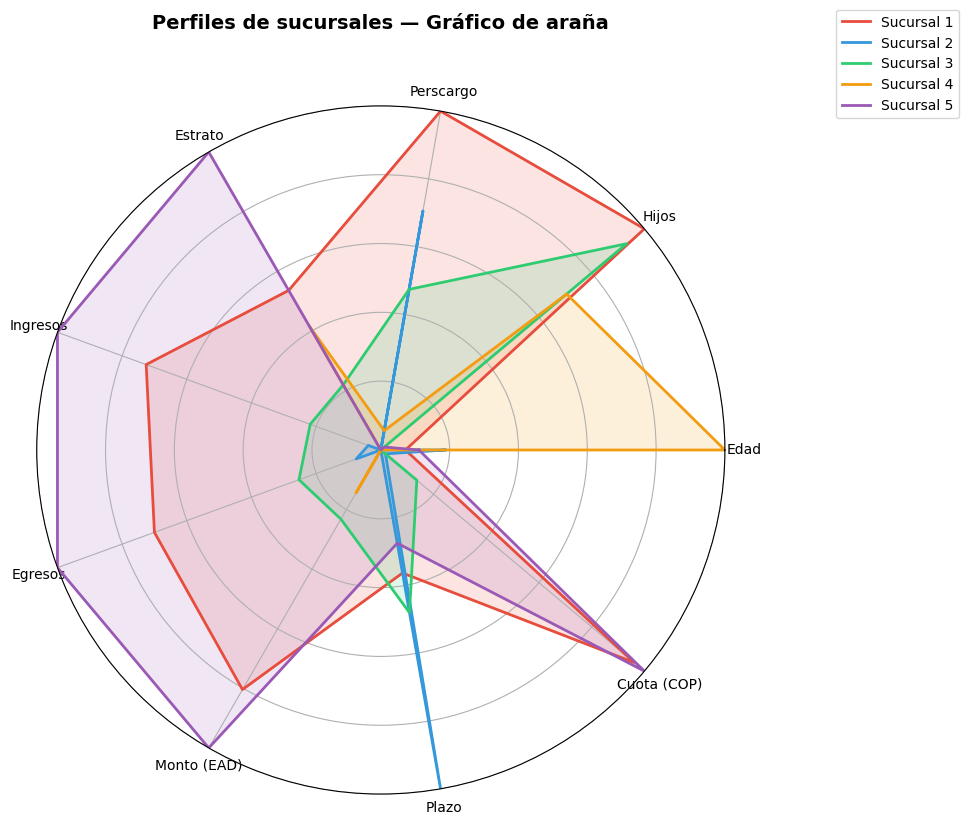

In [44]:
# Defino la función que dibuja el gráfico de araña para comparar los 5 perfiles
def radar_chart(df, features, title='Perfiles de sucursales — Gráfico de araña'):
    N = len(features)

    # Calculo el ángulo de cada eje distribuyéndolos uniformemente en el círculo
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]  # Cierro el polígono repitiendo el primer ángulo al final

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

    # Colores para cada sucursal
    colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

    # Dibujo el perfil de cada sucursal
    for i, row in df.iterrows():
        values = row[features].values.flatten().tolist()
        values += values[:1]  # Cierro el polígono
        ax.plot(angles, values, linewidth=2, linestyle='solid',
                label=row['Cluster'], color=colores[i])
        ax.fill(angles, values, alpha=0.15, color=colores[i])

    # Etiqueto cada eje con el nombre de la variable
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)

    # Oculto las etiquetas del eje radial porque los datos están normalizados
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])

    ax.set_title(title, y=1.1, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

    plt.tight_layout()
    plt.show()

# Llamo la función para generar el gráfico de araña
radar_chart(df_normalized, features)

## **Conclusiones y recomendaciones para la fintech**

- Los cinco clusters que lograron formarse usando Kmedois no tienen el mismo tamaño, lo que refleja que la demanda no está distribuida uniformemente en el territorio. La empresa debería dimensionar el personal y los recursos de cada sucursal en función del número de solicitantes asignados.

- Todos los municipios del Área Metropolitana (Caldas, Sabaneta, Bello, Itagüí, Medellín y Envigado) quedan representados dentro del modelo. Esto garantiza que ningún grupo de solicitantes queda desatendido en la nueva estructura.

- Cada sucursal presenta un perfil de riesgo distinto, evidenciado por los diferentes porcentajes de preaprobación y prenegación. Esto sugiere que los perfiles socioeconómicos de los solicitantes varían significativamente entre grupos, lo cual debe considerarse en el diseño de productos financieros para cada sucursal.

- El gráfico de araña muestra que las sucursales atienden perfiles de clientes claramente diferenciados. La Sucursal 5 concentra clientes de mayor nivel económico, con valores altos en ingresos, egresos, monto y estrato, lo que sugiere un segmento de alto valor. En contraste, la Sucursal 2 presenta clientes con bajos ingresos y estrato, pero con plazos de crédito más largos, indicando mayor dependencia de financiamiento. La Sucursal 1 exhibe un perfil sólido y relativamente alto en varias variables como cuota, hijos y responsabilidad financiera, mientras que la Sucursal 3 mantiene valores intermedios, representando un perfil más equilibrado. Por su parte, la Sucursal 4 agrupa clientes de mayor edad pero con menor capacidad económica relativa. En conjunto, el gráfico evidencia que cada sucursal maneja segmentos distintos, por lo que se recomienda orientar estrategias comerciales, de riesgo y de productos de forma más específica según el tipo de cliente.

Se concluye que el modelo logró concentrar toda la cartera de solicitantes en cinco grupos diferenciados, lo que permitirá a la empresa reorganizar su red de atención de manera eficiente sin pérdida de cobertura.
